# Analyzing the Adoption of Electric Vehicles in the Indian Market

**Rose Mary Varghese** · MS in Data Science and Management (IIM Indore + IIT Indore) · Capstone, Jan–Jun 2025 · revised for publication

This notebook combines a consumer survey I designed and ran (204 usable responses after removing one under-18 respondent) with public registration, charging-infrastructure, parliamentary and IEA data. It asks three questions:

1. **Market:** How fast is India's EV market growing, in which segments and states, and how does it compare with other markets?
2. **Consumers:** Among people living in India, how many intend to buy an EV next, what holds them back, and what distinguishes those who intend to buy?
3. **Economics:** Under what conditions does an electric car cost less to own than a petrol car?

**How to read this notebook.** Each section states what was done and then what the result does and does not support. Several results from the original capstone did not hold up on re-analysis; the corrections are explained where they occur and summarised in the README.

**Reproducibility.** Runs top to bottom once the third-party files are in `data/external/` (`python scripts/download_data.py`; see Section 1). The survey is read from `data/survey_anonymised.csv`, which `scripts/anonymise_survey.py` produces from the raw export. The raw export is not published.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.compose import make_column_transformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

DATA = Path("../data")
SEED = 42

# Categorical colours in a fixed order (colour-blind-validated palette)
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
GREY = "#8a8984"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#b5b4ad", "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.prop_cycle": plt.cycler(color=C),
    "lines.linewidth": 2, "lines.markersize": 5,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 60)


def wilson(k, n):
    # Proportion with a 95% Wilson interval, as a short string
    lo, hi = proportion_confint(k, n, method="wilson")
    return f"{k / n:.0%} [{lo:.0%}–{hi:.0%}]"


def thousands(ax, axis="y"):
    fmt = plt.FuncFormatter(lambda v, _: f"{v / 1e6:.1f}M" if abs(v) >= 1e6 else f"{v / 1e3:.0f}k" if abs(v) >= 1e3 else f"{v:.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

## 1. Data

| # | File | Contents | Source | Used for |
|---|---|---|---|---|
| 1 | `survey_anonymised.csv` | Own survey, Google Forms, 6–7 June 2025, 28 questions | This repository | Consumer intent, barriers, motivators |
| 2 | `EV_Dataset.csv` | EV registrations by state × month × vehicle class, 2014–Jan 2024 | [Kaggle: mafzal19](https://www.kaggle.com/datasets/mafzal19/electric-vehicle-sales-by-state-in-india), described there as scraped from the Clean Mobility Shift website | National and state trends, segments |
| 3 | `ev_sales_by_makers_and_cat_15-24.csv` | EV registrations by manufacturer and category, 2015–2024 | [Kaggle: srinrealyf](https://www.kaggle.com/datasets/srinrealyf/india-ev-market-data); upstream source not stated | Brand concentration |
| 4 | `OperationalPC.csv` | Operational public charging stations by state | [Kaggle: srinrealyf](https://www.kaggle.com/datasets/srinrealyf/india-ev-market-data); upstream source and snapshot date not stated | Infrastructure vs adoption |
| 5 | `RS_Session_265_AU_1355_A_and_B.csv` | Registered EVs by financial year, FY2019-20 to FY2023-24 (e-Vahan) | [data.gov.in](https://www.data.gov.in/resource/year-wise-number-registered-electric-vehicles-e-vahan-portal-2019-20-2023-24): Rajya Sabha Session 265, USQ 1355 | Cross-check of national totals |
| 6 | `RS_Session_259_AU_3475_1.csv` | Registered EVs by state, e-Vahan, as on 6 March 2023 | [data.gov.in](https://www.data.gov.in/resource/stateut-wise-details-registered-electric-vehicles-india-e-vahan-portal-ministry-road): Rajya Sabha Session 259, USQ 3475 | Cross-check of state ranking |
| 7 | `IEA Global EV Data 2024.csv` | EV stock, sales and shares by country, mode and powertrain | [IEA Global EV Outlook 2024 data product](https://www.iea.org/data-and-statistics/data-product/global-ev-outlook-2024) | International benchmark |

**Files 2–7 are not included in this repository**, because their redistribution terms could not be confirmed (see the README's *Data terms*). Run `python scripts/download_data.py` to fetch them into `data/external/`. The script downloads the Kaggle files automatically, gives instructions for the rest, and checks every file against the version this analysis used.

**Files from the original capstone that are not used** (and are not distributed): an `ev_adoption_dataset.csv` that appears synthetic (India's charging stations grow by exactly 10% a year), a `final_dataset.csv` with implausible state × category counts, and four files that overlap with dataset 2.

In [2]:
EXTERNAL = DATA / "external"
needed = ["EV_Dataset.csv", "ev_sales_by_makers_and_cat_15-24.csv", "OperationalPC.csv",
          "RS_Session_265_AU_1355_A_and_B.csv", "RS_Session_259_AU_3475_1.csv", "IEA Global EV Data 2024.csv"]
missing = [f for f in needed if not (EXTERNAL / f).exists()]
if missing:
    raise FileNotFoundError(f"Missing from data/external/: {missing}. Run `python scripts/download_data.py` "
                            "from the repository root (see README).")

survey = pd.read_csv(DATA / "survey_anonymised.csv")
ev = pd.read_csv(EXTERNAL / "EV_Dataset.csv")
brands = pd.read_csv(EXTERNAL / "ev_sales_by_makers_and_cat_15-24.csv")
chargers = pd.read_csv(EXTERNAL / "OperationalPC.csv")
rs_year = pd.read_csv(EXTERNAL / "RS_Session_265_AU_1355_A_and_B.csv")
rs_state = pd.read_csv(EXTERNAL / "RS_Session_259_AU_3475_1.csv")
iea = pd.read_csv(EXTERNAL / "IEA Global EV Data 2024.csv")

ev["Year"] = ev["Year"].astype(int)
for name, df in [("survey", survey), ("ev", ev), ("brands", brands), ("chargers", chargers),
                 ("rs_year", rs_year), ("rs_state", rs_state), ("iea", iea)]:
    print(f"{name:9s} {df.shape}")

survey    (204, 63)
ev        (96845, 8)
brands    (1386, 12)
chargers  (34, 2)
rs_year   (5, 2)
rs_state  (35, 3)
iea       (12654, 8)


### 1.1 Coverage checks on the registration data

Two properties of `EV_Dataset.csv` matter for everything that follows:

- **2024 contains January only.** It is a partial year, not a decline. All annual analysis uses 2014–2023.
- **Telangana is absent.** "All-India" totals from this file exclude one of the larger state markets.

In [3]:
months = ev.groupby("Year")["Month_Name"].nunique()
print("Months of data per year:", months.to_dict())
print("States in file:", ev["State"].nunique(), "| Telangana present:", "Telangana" in set(ev["State"]))

annual = ev.groupby("Year")["EV_Sales_Quantity"].sum()
full_years = annual.loc[2014:2023]

# Cross-check against parliamentary figures (financial years, so only roughly comparable)
fy = ev.assign(FY=np.where(ev["Month_Name"].isin(["jan", "feb", "mar"]), ev["Year"] - 1, ev["Year"]))
fy = fy[fy["FY"].between(2019, 2022)].groupby("FY")["EV_Sales_Quantity"].sum()
check = pd.DataFrame({
    "Rajya Sabha": rs_year.set_index("Year")["Number of Registered Electric Vehicles"].iloc[:4].values,
    "EV_Dataset (same FY)": fy.values,
}, index=rs_year["Year"].iloc[:4])
check["Ratio"] = (check["EV_Dataset (same FY)"] / check["Rajya Sabha"]).round(2)
check

Months of data per year: {2014: 12, 2015: 12, 2016: 12, 2017: 12, 2018: 12, 2019: 12, 2020: 12, 2021: 12, 2022: 12, 2023: 12, 2024: 1}
States in file: 34 | Telangana present: False


,Rajya Sabha,EV_Dataset (same FY),Ratio
Year,,,
2019-20,173604,173558.0,1.0
2020-21,142383,142397.0,1.0
2021-22,459058,458897.0,1.0
2022-23,1183341,1182951.0,1.0


The registration file matches the government's figures to within 0.1% in every financial year. That suggests both come from the same Vahan source, so this is a consistency check rather than independent confirmation. The file is a reasonable basis for national trends, with the Telangana gap noted.

## 2. The survey sample

The survey was distributed through personal networks and collected over roughly 20 hours on 6–7 June 2025. It is a **convenience sample**. Its composition determines what it can and cannot say.

In [4]:
survey["intent"] = survey["purchase_intent"].isin(["Very likely", "Somewhat likely"]).astype(int)

print("Residential status vs. where the respondent says they live")
print(pd.crosstab(survey["residential_status"], survey["lives_in_india"].map({1: "Lives in India", 0: "Lives abroad / unclear"}), margins=True), "\n")
print("Region:", survey["region"].value_counts().to_dict())
print("Gender:", survey["gender"].value_counts().to_dict())
print("Area type:", survey["area_type"].value_counts().to_dict())

Residential status vs. where the respondent says they live
lives_in_india      Lives abroad / unclear  Lives in India  All
residential_status                                             
Foreign national                         2               2    4
Indian resident                          6             125  131
NRI                                     66               3   69
All                                     74             130  204 

Region: {'Kerala': 58, 'Gulf': 49, 'Suppressed': 40, 'Other Indian state': 25, 'Tamil Nadu': 19, 'Other abroad': 10, 'India, unspecified': 3}
Gender: {'Female': 124, 'Male': 78, 'Prefer not to say': 2}
Area type: {'Metro city': 104, 'Urban (non-metro city or town)': 71, 'Semi-urban': 17, 'Rural': 12}


**What the sample is:** it skews heavily towards Kerala and the Gulf diaspora, towards women (61%, whereas vehicle buyers in India are predominantly men), and towards people with degrees (94%). A third of respondents are Non-Resident Indians.

**Defining the analysis sample.** The project is about the Indian market, so the headline analysis uses **respondents who are Indian residents *and* report living in India (n = 125)**. Six self-described residents gave a location abroad (or one that could not be placed) and are excluded from the headline sample. This is a strict definition chosen to avoid mixing markets; with n = 125 every percentage below has a confidence interval of roughly ±9 points.

NRIs (n = 69) are analysed separately in Section 4. The four foreign nationals are excluded from both.

In [5]:
india = survey[(survey["residential_status"] == "Indian resident") & (survey["lives_in_india"] == 1)].copy()
nri = survey[survey["residential_status"] == "NRI"].copy()
print(f"Indian residents living in India: n = {len(india)}")
print(f"NRIs: n = {len(nri)}")

Indian residents living in India: n = 125
NRIs: n = 69


## 3. Indian residents: intent, barriers, motivators

### 3.1 Purchase intent
"Likely to buy" = *Very likely* or *Somewhat likely* to make their next vehicle an EV. This is **stated intent**, which typically overstates actual purchase.

Likely to buy: 44% [36%–53%]


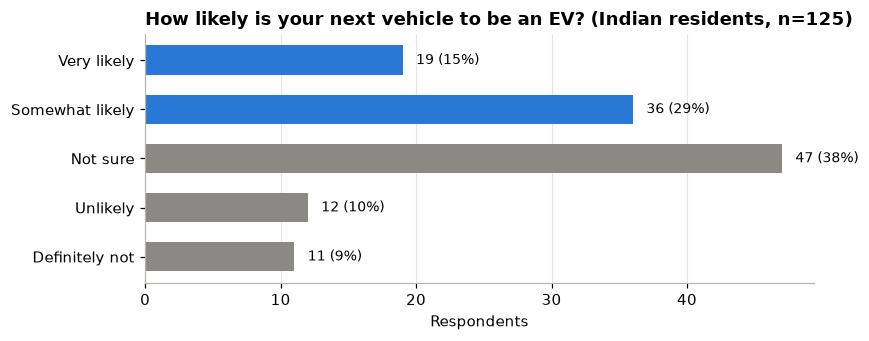

In [6]:
order = ["Definitely not", "Unlikely", "Not sure", "Somewhat likely", "Very likely"]
counts = india["purchase_intent"].value_counts().reindex(order)
print("Likely to buy:", wilson(india["intent"].sum(), len(india)))

fig, ax = plt.subplots(figsize=(8, 3.2))
colors = [GREY, GREY, GREY, C[0], C[0]]
ax.barh(order, counts.values, color=colors, height=0.6)
for i, v in enumerate(counts.values):
    ax.text(v + 1, i, f"{v} ({v / len(india):.0%})", va="center", fontsize=9)
ax.set_title(f"How likely is your next vehicle to be an EV? (Indian residents, n={len(india)})")
ax.set_xlabel("Respondents")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

44% say they are likely to buy an EV next (95% CI 36–53%). The largest single group, 38%, is **undecided**, which is arguably the more useful finding: the persuadable middle is large.

### 3.2 Barriers, motivators and preferred charging location
Multi-select questions, so shares sum to more than 100%. Brackets are 95% confidence intervals.

In [7]:
def share_table(df, prefix):
    s = df.filter(like=prefix).sum().sort_values(ascending=False)
    n = len(df)
    return pd.DataFrame({
        "share": (s / n).round(3).values,
        "95% CI": [wilson(k, n) for k in s],
    }, index=[c.replace(prefix, "") for c in s.index])

concerns = share_table(india, "concern_")
motivators = share_table(india, "motivator_")
charging = share_table(india, "charge_at_")
display(concerns, motivators, charging)

,share,95% CI
charging_infra,0.560,56% [47%–64%]
upfront_cost,0.512,51% [43%–60%]
battery_cost,0.504,50% [42%–59%]
range,0.432,43% [35%–52%]
charging_time,0.408,41% [33%–50%]
resale_value,0.320,32% [24%–41%]
safety,0.272,27% [20%–36%]
performance,0.168,17% [11%–24%]
none_not_sure,0.064,6% [3%–12%]


,share,95% CI
better_charging,0.416,42% [33%–50%]
environment,0.408,41% [33%–50%]
fuel_prices,0.368,37% [29%–46%]
lower_price,0.352,35% [27%–44%]
faster_charging,0.320,32% [24%–41%]
incentives,0.232,23% [17%–31%]
peers,0.064,6% [3%–12%]


,share,95% CI
home,0.640,64% [55%–72%]
public,0.368,37% [29%–46%]
anywhere,0.296,30% [22%–38%]
work,0.272,27% [20%–36%]
malls_highways,0.256,26% [19%–34%]


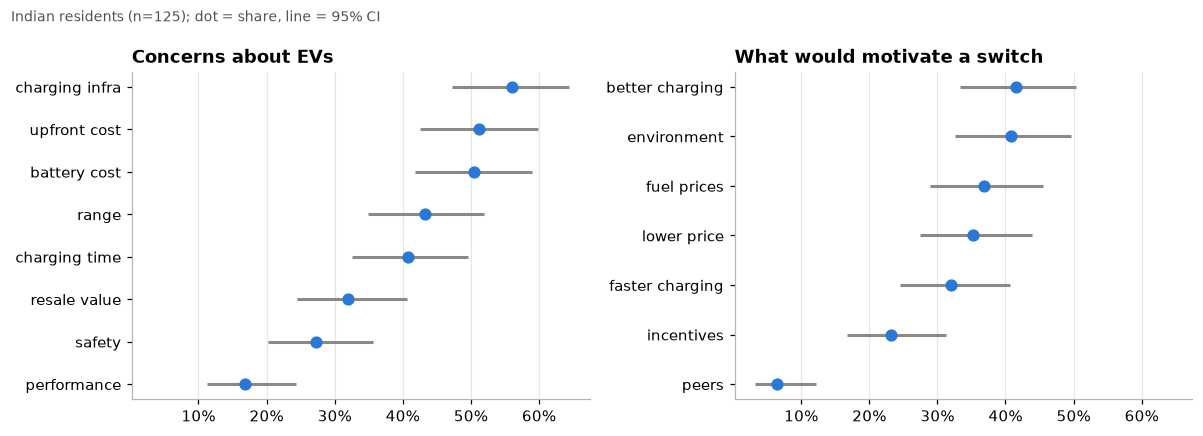

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, tbl, title in [(axes[0], concerns.drop("none_not_sure"), "Concerns about EVs"),
                       (axes[1], motivators, "What would motivate a switch")]:
    n = len(india)
    k = (tbl["share"] * n).round().astype(int)
    lo, hi = proportion_confint(k, n, method="wilson")
    y = np.arange(len(tbl))[::-1]
    ax.hlines(y, lo, hi, color=GREY, linewidth=2)
    ax.plot(tbl["share"], y, "o", color=C[0], markersize=7)
    ax.set_yticks(y, [s.replace("_", " ") for s in tbl.index])
    ax.set_title(title)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.grid(axis="y", visible=False)
fig.suptitle(f"Indian residents (n={len(india)}); dot = share, line = 95% CI", x=0.01, ha="left", fontsize=9, color="#52514e")
plt.tight_layout()
plt.show()

**What holds up:**
- The top three concerns, **charging infrastructure (56%), upfront cost (51%) and battery replacement cost (50%)**, are each cited by about half of respondents. Their confidence intervals overlap, so the data **cannot rank them** against each other. It can say they sit clearly above safety (27%) and performance (17%).
- **Home is the preferred charging location (64%)**, well ahead of public stations (37%).
- On motivators, better charging, environmental impact, fuel prices and a lower purchase price all fall in the 32–42% range and **cannot be separated statistically**. Peer influence is clearly last (6%).

**What does not hold up:** a ranked "#1 barrier" claim.

### 3.3 Who intends to buy? Bivariate associations
Intent rate by each variable, with a chi-square test. With this many tests, some will look significant by chance, so p-values are also shown after Holm correction.

In [9]:
candidates = ["opinion", "suitable_for_area", "familiarity", "gender", "income_band", "area_type",
              "policy_awareness", "pay_extra_fast_charging", "charging_time", "owns_vehicle",
              "age_band", "education", "financial_situation"]
rows = []
for c in candidates:
    tab = pd.crosstab(india[c], india["intent"])
    p = stats.chi2_contingency(tab)[1]
    rates = india.groupby(c)["intent"].agg(["sum", "count"])
    detail = "; ".join(f"{k}: {r['sum']}/{r['count']}" for k, r in rates.iterrows())
    rows.append({"variable": c, "p": p, "intent by level": detail})
assoc = pd.DataFrame(rows)
assoc["p (Holm)"] = multipletests(assoc["p"], method="holm")[1]
assoc = assoc.sort_values("p").set_index("variable")
assoc[["p", "p (Holm)"]] = assoc[["p", "p (Holm)"]].round(3)
with pd.option_context("display.max_colwidth", 200):
    display(assoc)

,p,intent by level,p (Holm)
variable,,,
opinion,0.000,Neutral: 2/28; Somewhat negative: 1/7; Somewhat positive: 27/56; Very negative: 0/1; Very positive: 25/33,0.000
suitable_for_area,0.000,"Maybe - depends on infrastructure: 22/58; No- not suitable due to roads, power supply, etc.: 1/15; Not sure: 1/4; Yes, definitely: 31/48",0.005
gender,0.012,Female: 24/70; Male: 31/53; Prefer not to say: 0/2,0.137
familiarity,0.027,Heard of them: 8/20; Not familiar at all: 0/9; Somewhat familiar: 28/62; Very familiar: 19/34,0.269
income_band,0.126,1L–2L: 9/12; 20k–50k: 16/31; 2L–5L: 2/5; 50k–1L: 12/24; <20k: 5/17; >5L: 3/11; Prefer not to say: 8/25,1.000
area_type,0.127,Metro city: 23/43; Rural: 3/12; Semi-urban: 3/13; Urban (non-metro city or town): 26/57,1.000
charging_time,0.178,1- 2 hours: 8/22; 30 minutes - 1 hour: 18/41; Doesn't matter: 1/7; Less than 30 minutes: 22/47; Overnight ( 6 - 8 hours): 6/8,1.000
policy_awareness,0.279,"Aware to some extent: 19/35; Have heard of them but unsure of details: 13/33; No, not aware: 13/38; Yes, well aware: 10/19",1.000
pay_extra_fast_charging,0.311,Depends on how much extra: 25/62; No: 15/33; Not sure: 2/8; Yes: 13/22,1.000


**Reading this table:**
- Only **overall opinion of EVs** and **"are EVs suitable for your area?"** remain significant after correction. Both are attitudes, and both are close to restating purchase intent in different words. Someone who thinks EVs are "the future of transportation" is, almost by definition, more likely to say they will buy one.
- **Gender** shows a raw gap (men 31/53 = 58% vs women 24/70 = 34%, unadjusted p = 0.01), but it **does not survive correction** for the number of tests. It is a hypothesis for a larger sample, not a finding. It may also reflect who makes vehicle decisions in a household rather than a preference.
- Income, area type, age, education, vehicle ownership and policy awareness show **no detectable association** at this sample size.

## 4. NRIs vs Indian residents

NRIs mostly live in the Gulf, where vehicle markets, fuel prices and charging access are very different. Mixing them into the Indian analysis would blur both groups, so they are compared separately here.

In [10]:
both = pd.concat([india.assign(group="Indian resident"), nri.assign(group="NRI")])
print("Likely to buy an EV next:")
for g, df in both.groupby("group"):
    print(f"  {g:16s} n={len(df):3d}  {wilson(df['intent'].sum(), len(df))}")
tab = pd.crosstab(both["group"], both["intent"])
print(f"Fisher exact p = {stats.fisher_exact(tab.values)[1]:.2f}\n")
print(pd.crosstab(both["group"], both["purchase_intent"], normalize="index")[order].round(2))

conc = pd.DataFrame({g: df.filter(like="concern_").mean() for g, df in both.groupby("group")}).round(2)
conc.index = conc.index.str.replace("concern_", "")
conc.sort_values("Indian resident", ascending=False)

Likely to buy an EV next:
  Indian resident  n=125  44% [36%–53%]
  NRI              n= 69  48% [36%–59%]
Fisher exact p = 0.65

purchase_intent  Definitely not  Unlikely  Not sure  Somewhat likely  Very likely
group                                                                            
Indian resident            0.09      0.10      0.38             0.29         0.15
NRI                        0.06      0.14      0.32             0.30         0.17


,Indian resident,NRI
charging_infra,0.56,0.58
upfront_cost,0.51,0.58
battery_cost,0.50,0.46
range,0.43,0.45
charging_time,0.41,0.52
resale_value,0.32,0.35
safety,0.27,0.29
performance,0.17,0.33
none_not_sure,0.06,0.04


**Result:** stated intent is **statistically indistinguishable** between NRIs (48%) and Indian residents (44%) (Fisher p = 0.65). Concern profiles are broadly similar, except that NRIs cite performance concerns about twice as often (33% vs 17%), a single comparison that should not be over-read. On purchase intent, this sample shows no NRI effect. Including NRIs in the original headline numbers therefore did not materially change them, but the separation is still the correct design.

## 5. Can purchase intent be predicted?

### What changed from the original capstone
- The original logistic regression reported **75.6% accuracy on a single 41-row holdout**. With so few rows, a single split's accuracy has a standard error of about ±7 points, and the majority-class baseline was 55.6%.
- Its top predictor was **"overall opinion = Very positive"** (coef 2.79). Predicting "I'll buy an EV" from "I think EVs are the future" is close to circular.
- A separate RandomForest reported **39% accuracy on a 5-class target with 4 features**. With 5 classes and the largest class at 37%, that is barely above guessing the most common answer, and it is not comparable with a binary model.

### Approach here
- **Same binary target, same folds, same features for every model.** 5-fold stratified cross-validation repeated 20 times (100 fits per model), reporting the mean ± standard deviation of accuracy and ROC AUC.
- Three feature sets:
  - **Full**: demographics + behaviour + attitudes (opinion, familiarity). This mirrors the original model.
  - **Demographic & behavioural only**: age, gender, area type, education, employment, income, financial situation, vehicle ownership, vehicle age, monthly distance.
  - **Attitudes only**: opinion and familiarity.
- Logistic regression and random forest are each fitted on every feature set, so they are compared like for like.

In [11]:
demo = ["age_band", "gender", "area_type", "education", "employment", "income_band",
        "financial_situation", "owns_vehicle", "vehicle_age", "monthly_distance"]
attitudes = ["familiarity", "opinion"]
feature_sets = {"Full (original spec)": demo + attitudes,
                "Demographic & behavioural only": demo,
                "Attitudes only": attitudes}
models = {"Majority-class baseline": DummyClassifier(strategy="most_frequent"),
          "Logistic regression": LogisticRegression(max_iter=2000),
          "Random forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=SEED)}
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=SEED)


def evaluate(df):
    out = []
    for fs_name, cols in feature_sets.items():
        for m_name, model in models.items():
            if m_name.startswith("Majority") and fs_name != "Full (original spec)":
                continue
            pipe = make_pipeline(
                make_column_transformer((OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cols)),
                model)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                r = cross_validate(pipe, df[cols], df["intent"], cv=cv, scoring=["accuracy", "roc_auc"])
            out.append({"features": "—" if m_name.startswith("Majority") else fs_name, "model": m_name,
                        "accuracy": f"{r['test_accuracy'].mean():.3f} ± {r['test_accuracy'].std():.3f}",
                        "ROC AUC": f"{r['test_roc_auc'].mean():.3f} ± {r['test_roc_auc'].std():.3f}"})
    return pd.DataFrame(out).set_index(["features", "model"])


print(f"Indian residents, n={len(india)}, share likely to buy={india['intent'].mean():.1%}")
results_india = evaluate(india)
results_india

Indian residents, n=125, share likely to buy=44.0%


accuracy        ROC AUC
features                       model                                                
—                              Majority-class baseline  0.560 ± 0.000  0.500 ± 0.000
Full (original spec)           Logistic regression      0.644 ± 0.091  0.713 ± 0.089
                               Random forest            0.693 ± 0.078  0.736 ± 0.094
Demographic & behavioural only Logistic regression      0.519 ± 0.093  0.507 ± 0.113
                               Random forest            0.558 ± 0.088  0.519 ± 0.112
Attitudes only                 Logistic regression      0.660 ± 0.071  0.769 ± 0.073
                               Random forest            0.667 ± 0.074  0.783 ± 0.077

In [12]:
print(f"Whole sample (incl. NRIs), n={len(survey)} — for comparison with the original model")
evaluate(survey)

Whole sample (incl. NRIs), n=204 — for comparison with the original model


accuracy        ROC AUC
features                       model                                                
—                              Majority-class baseline  0.554 ± 0.010  0.500 ± 0.000
Full (original spec)           Logistic regression      0.716 ± 0.070  0.779 ± 0.073
                               Random forest            0.738 ± 0.067  0.794 ± 0.070
Demographic & behavioural only Logistic regression      0.553 ± 0.078  0.567 ± 0.087
                               Random forest            0.579 ± 0.069  0.590 ± 0.085
Attitudes only                 Logistic regression      0.705 ± 0.064  0.803 ± 0.063
                               Random forest            0.700 ± 0.061  0.801 ± 0.060

**What the models show:**
- **Demographic and behavioural variables have no predictive power.** For Indian residents, the demographic-only models score an AUC of about 0.5 (no better than a coin) and accuracy at or below the majority baseline.
- **All of the predictive signal comes from attitudes.** The attitudes-only model (two questions) does as well as the full model.
- **Random forest vs logistic regression:** on the same target, features and folds, the two are within noise of each other. The original "39% vs 75.6%" gap came entirely from comparing a 5-class problem with a binary one.
- Fold-to-fold variation (±7–9 accuracy points) is the honest measure of uncertainty with n = 125. The original single-split 75.6% sat within that range by chance.

**Conclusion:** this survey **cannot identify demographic segments** that are more likely to adopt EVs. Its usable output is descriptive: the size of the undecided group, the barrier and motivator shares, and the charging preferences. The "drivers of adoption" claim from the original model is withdrawn.

For transparency, the coefficients of the full logistic model (fitted on all Indian residents) are shown below. They are descriptive only. The largest coefficients in both directions are attitude terms (opinion, familiarity).

In [13]:
cols = demo + attitudes
pipe = make_pipeline(make_column_transformer((OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cols)),
                     LogisticRegression(max_iter=2000))
pipe.fit(india[cols], india["intent"])
names = pipe[0].get_feature_names_out()
coef = pd.Series(pipe[-1].coef_[0], index=[n.split("__", 1)[1] for n in names]).sort_values()
pd.concat([coef.head(5), coef.tail(5)]).round(2).to_frame("coefficient (log-odds, L2-regularised)")

,"coefficient (log-odds, L2-regularised)"
opinion_Neutral,-1.59
familiarity_Not familiar at all,-1.42
employment_Homemaker,-0.83
opinion_Somewhat negative,-0.64
area_type_Rural,-0.62
gender_Male,0.59
familiarity_Heard of them,0.65
monthly_distance_not applicable,0.74
employment_Not working,0.85
opinion_Very positive,1.93


## 6. The Indian EV market

### 6.1 National trend and segment mix

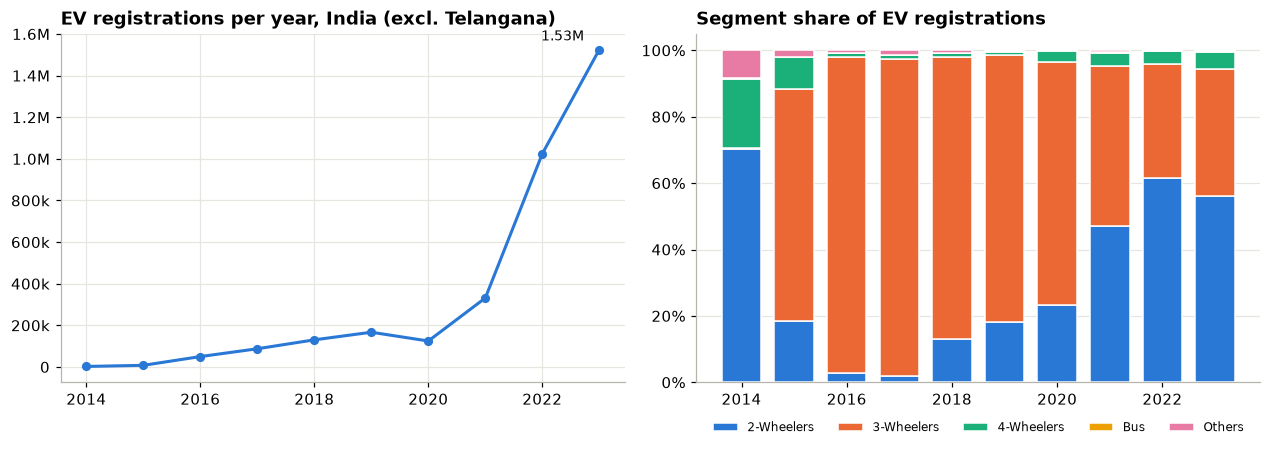

Year             2014     2015      2016      2017       2018       2019       2020       2021        2022        2023
registrations  2392.0  7805.00  49855.00  87420.00  130254.00  166819.00  124684.00  331498.00  1024723.00  1525179.00
YoY growth        NaN     2.26      5.39      0.75       0.49       0.28      -0.25       1.66        2.09        0.49

2023 segment shares: {'2-Wheelers': 0.562, '3-Wheelers': 0.382, '4-Wheelers': 0.053, 'Bus': 0.002, 'Others': 0.002}


In [14]:
seg = ev[ev["Year"].between(2014, 2023)].pivot_table(index="Year", columns="Vehicle_Category",
                                                     values="EV_Sales_Quantity", aggfunc="sum")
seg = seg[["2-Wheelers", "3-Wheelers", "4-Wheelers", "Bus", "Others"]]
share = seg.div(seg.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
ax.plot(full_years.index, full_years.values, marker="o", color=C[0])
ax.set_title("EV registrations per year, India (excl. Telangana)")
thousands(ax)
ax.annotate(f"{full_years[2023] / 1e6:.2f}M", (2023, full_years[2023]), textcoords="offset points",
            xytext=(-10, 6), ha="right", fontsize=9)

ax = axes[1]
bottom = np.zeros(len(share))
for i, c in enumerate(share.columns):
    ax.bar(share.index, share[c], bottom=bottom, color=C[i], label=c, width=0.75, edgecolor="white", linewidth=1)
    bottom += share[c].values
ax.set_title("Segment share of EV registrations")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(ncol=5, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.08), frameon=False)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({"registrations": full_years.astype(int), "YoY growth": full_years.pct_change().round(2)})
print(summary.T.to_string())
print("\n2023 segment shares:", share.loc[2023].round(3).to_dict())

- Registrations rose from 2,392 in 2014 to **1.53 million in 2023**. The single 2020 dip coincides with COVID-19.
- **Growth is decelerating:** +209% in 2022, then +49% in 2023. This matters for the forecast in Section 8.
- **India's EV market is two- and three-wheelers:** together they were 94% of 2023 registrations, and cars only 5%. This is why the car-based international comparison in Section 9 understates India's position.

### 6.2 States: concentration and growth

Top 10 states = 79% of 2023 registrations; Uttar Pradesh alone = 18%
States with ≥1,000 registrations in 2019: 17 of 34


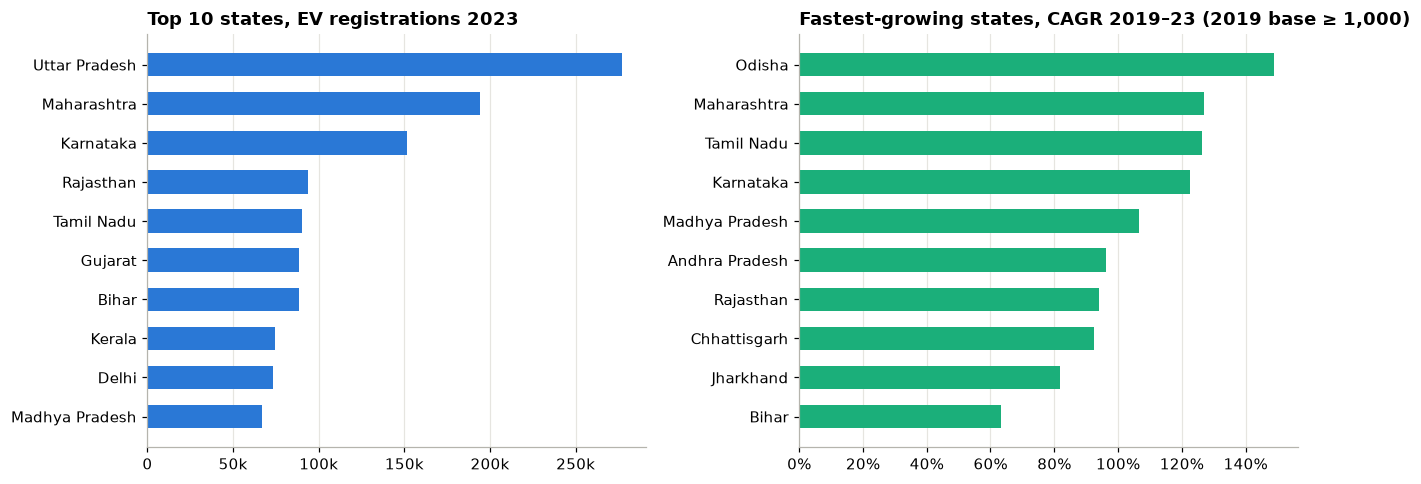

Year,2019,2023,CAGR 2019–23
State,,,
Odisha,1159.0,44552.0,1.49
Maharashtra,7319.0,193935.0,1.27
Tamil Nadu,3444.0,90242.0,1.26
Karnataka,6152.0,151272.0,1.23
Madhya Pradesh,3680.0,67051.0,1.07
Andhra Pradesh,2123.0,31506.0,0.96
Rajasthan,6633.0,93818.0,0.94
Chhattisgarh,2744.0,37638.0,0.92
Jharkhand,1931.0,21097.0,0.82


In [15]:
state_year = ev[ev["Year"].between(2019, 2023)].pivot_table(index="State", columns="Year",
                                                            values="EV_Sales_Quantity", aggfunc="sum")
s23 = state_year[2023].sort_values(ascending=False)
top10_share = s23.head(10).sum() / s23.sum()
print(f"Top 10 states = {top10_share:.0%} of 2023 registrations; Uttar Pradesh alone = {s23.iloc[0] / s23.sum():.0%}")

# CAGR 2019–23, only for states with a meaningful 2019 base (small bases give meaningless rates)
MIN_BASE = 1000
g = state_year[state_year[2019] >= MIN_BASE].copy()
g["CAGR 2019–23"] = (g[2023] / g[2019]) ** (1 / 4) - 1
print(f"States with ≥{MIN_BASE:,} registrations in 2019: {len(g)} of {len(state_year)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
top = s23.head(10)[::-1]
ax.barh(top.index, top.values, color=C[0], height=0.6)
ax.set_title("Top 10 states, EV registrations 2023")
thousands(ax, "x")
ax.grid(axis="y", visible=False)
ax = axes[1]
gg = g["CAGR 2019–23"].sort_values().tail(10)
ax.barh(gg.index, gg.values, color=C[2], height=0.6)
ax.set_title(f"Fastest-growing states, CAGR 2019–23 (2019 base ≥ {MIN_BASE:,})")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()
g.sort_values("CAGR 2019–23", ascending=False)[[2019, 2023, "CAGR 2019–23"]].head(10).round(2)

The original CAGR table ranked Ladakh first with an infinite growth rate (0 → 28 vehicles) and Mizoram third (1 → 166). Rates from tiny bases are not informative, so states with fewer than 1,000 registrations in 2019 are excluded here.

As a cross-check, the state ranking from this file is compared with the cumulative state counts that the government reported to the Rajya Sabha:

In [16]:
cum = ev.groupby("State")["EV_Sales_Quantity"].sum()
rs = rs_state[rs_state["State Name"] != "Grand Total"].set_index("State Name")["Electric Vehicle Count"]
rs = rs.rename({"Andaman and Nicobar Island": "Andaman & Nicobar Island",
                "Dadra and Nagar Haveli and Daman and Diu": "DNH and DD"})
both_rank = pd.concat([cum, rs], axis=1, keys=["EV_Dataset cumulative", "Rajya Sabha"]).dropna()
rho = stats.spearmanr(both_rank.iloc[:, 0], both_rank.iloc[:, 1])[0]
print(f"States matched: {len(both_rank)}; Spearman rank correlation = {rho:.2f}")

States matched: 34; Spearman rank correlation = 0.99


The state rankings agree closely across the two sources. Absolute levels differ because the snapshot dates and definitions differ, so only the rankings are compared.

### 6.3 Brand concentration
In the original notebook the "4W" brand chart was empty because the dataset labels cars `LMV`. That is fixed here. 2024 in this file is a partial year, so 2023 is used.

In [17]:
brands["Cat"] = brands["Cat"].str.strip()
rows = []
for cat in ["2W", "3W", "LMV"]:
    b = brands[brands["Cat"] == cat].set_index("Maker")["2023"].astype(float).sort_values(ascending=False)
    shares = b / b.sum()
    hhi = (shares ** 2).sum() * 10_000
    rows.append({"category": cat, "2023 units": int(b.sum()), "top maker": b.index[0].title(),
                 "top maker share": f"{shares.iloc[0]:.0%}", "top 3 share": f"{shares.head(3).sum():.0%}",
                 "HHI": int(hhi)})
pd.DataFrame(rows).set_index("category")

,2023 units,top maker,top maker share,top 3 share,HHI
category,,,,,
2W,860398,Ola Electric Technologies Pvt Ltd,31%,63%,1628
3W,583712,Yc Electric Vehicle,7%,19%,220
LMV,84829,Tata Passenger Electric Mobility Ltd,45%,82%,2882


Concentration differs sharply by segment. Electric cars (LMV) are highly concentrated: Tata holds 45% and the top three makers 82%. Two-wheelers are moderately concentrated. Three-wheelers are fragmented across many small makers. (HHI above 2,500 is conventionally "highly concentrated"; below 1,500 is "unconcentrated".)

## 7. Charging infrastructure and adoption

### What changed
The original notebook ran the same charging-stations-vs-sales regression three times, the K-means clustering twice and the merge twice. It also silently lost states in the merge because names differed between files ("Pondicherry" vs "Puducherry", "Andaman & Nicobar" vs "Andaman & Nicobar Island", "D&D and DNH" vs "DNH and DD"), and it filled missing station counts with zero. This section does each step once, harmonises state names, and drops states missing from either file instead of zero-filling them.

Dropped (in only one file): ['Mizoram', 'Ladakh', 'Lakshadweep', 'Telangana']
n = 32 states (log-scale analyses exclude ['Sikkim'], which had 0 registrations)
Pearson r (raw)       = 0.65  (driven by a few large states)
Spearman rho (ranks)  = 0.92
Pearson r (log–log)   = 0.86
Log–log slope = 1.29: a state with 10% more stations has ~13% more registrations (association, not effect)


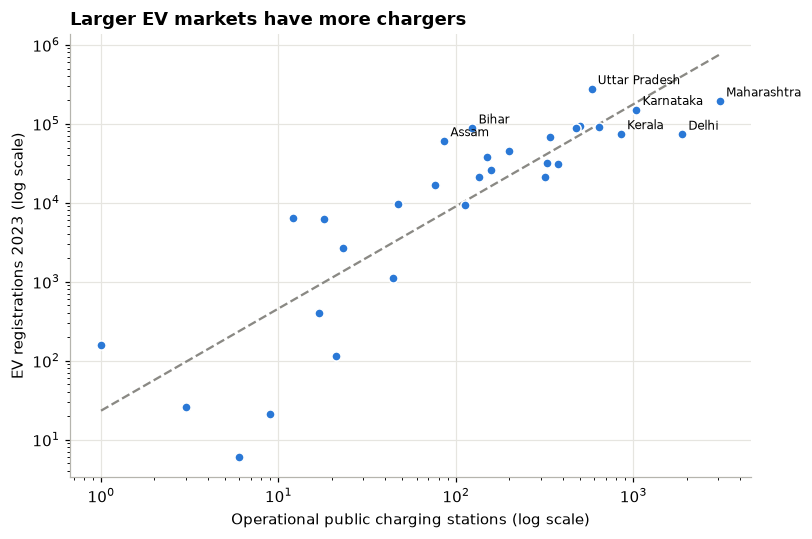

In [18]:
name_fix = {"Andaman & Nicobar": "Andaman & Nicobar Island", "D&D and DNH": "DNH and DD",
            "Pondicherry": "Puducherry"}
pcs = chargers.assign(State=chargers["State"].replace(name_fix)).set_index("State")["No. of Operational PCS"]
infra = pd.concat([s23.rename("sales_2023"), pcs.rename("stations")], axis=1)
print("Dropped (in only one file):", infra[infra.isna().any(axis=1)].index.tolist())
infra = infra.dropna()

r_p = stats.pearsonr(infra["sales_2023"], infra["stations"])
r_s = stats.spearmanr(infra["sales_2023"], infra["stations"])
# Log scale needs positive values; Sikkim recorded 0 registrations in 2023
zero = infra.index[infra["sales_2023"] == 0].tolist()
pos = infra.drop(zero)
r_log = stats.pearsonr(np.log10(pos["sales_2023"]), np.log10(pos["stations"]))
print(f"n = {len(infra)} states (log-scale analyses exclude {zero}, which had 0 registrations)")
print(f"Pearson r (raw)       = {r_p[0]:.2f}  (driven by a few large states)")
print(f"Spearman rho (ranks)  = {r_s[0]:.2f}")
print(f"Pearson r (log–log)   = {r_log[0]:.2f}")

slope, intercept = np.polyfit(np.log10(pos["stations"]), np.log10(pos["sales_2023"]), 1)
print(f"Log–log slope = {slope:.2f}: a state with 10% more stations has ~{slope * 10:.0f}% more registrations (association, not effect)")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(pos["stations"], pos["sales_2023"], s=36, color=C[0], edgecolor="white", linewidth=1, zorder=3)
xs = np.logspace(0, np.log10(pos["stations"].max()), 50)
ax.plot(xs, 10 ** (intercept + slope * np.log10(xs)), color=GREY, linewidth=1.5, linestyle="--")
for st in ["Maharashtra", "Delhi", "Uttar Pradesh", "Karnataka", "Kerala", "Bihar", "Assam"]:
    if st in pos.index:
        ax.annotate(st, (pos.loc[st, "stations"], pos.loc[st, "sales_2023"]), fontsize=8,
                    xytext=(4, 3), textcoords="offset points")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Operational public charging stations (log scale)")
ax.set_ylabel("EV registrations 2023 (log scale)")
ax.set_title("Larger EV markets have more chargers")
plt.tight_layout()
plt.show()

In [19]:
# Which states sit far above / below the trend line, and what do they sell?
resid = np.log10(pos["sales_2023"]) - (intercept + slope * np.log10(pos["stations"]))
mix23 = ev[ev["Year"] == 2023].pivot_table(index="State", columns="Vehicle_Category",
                                           values="EV_Sales_Quantity", aggfunc="sum")
three_w = (mix23["3-Wheelers"] / mix23.sum(axis=1)).rename("3W share of 2023 EVs")
out = pd.concat([resid.rename("log10 residual"), three_w], axis=1).loc[pos.index]
big = out[pos["sales_2023"] > 50_000].sort_values("log10 residual", ascending=False)
print(big.round(2).to_string())
print(f"\nCorrelation of residual with 3W share (states >50k EVs): {big.corr().iloc[0, 1]:.2f}")

                log10 residual  3W share of 2023 EVs
State                                               
Assam                     0.91                  0.95
Bihar                     0.87                  0.85
Uttar Pradesh             0.50                  0.84
Madhya Pradesh            0.18                  0.44
Gujarat                   0.12                  0.03
Rajasthan                 0.11                  0.32
Tamil Nadu               -0.04                  0.06
Karnataka                -0.09                  0.04
Kerala                   -0.28                  0.05
Maharashtra              -0.59                  0.06
Delhi                    -0.74                  0.36

Correlation of residual with 3W share (states >50k EVs): 0.77


**What holds up:** states with more public charging stations have more EV registrations. The rank correlation is strong (ρ ≈ 0.9).

**What does not:** any causal reading. Three problems:
1. **State size confounds it.** Large, populous, richer states have more of everything. No population or total-vehicle data is available here to normalise by, so this association cannot be separated from size.
2. **Direction is ambiguous.** Chargers are built where EVs already are, as much as the other way round.
3. **Unknown provenance and timing.** The charger file does not state its original source or snapshot date, while sales are 2023.

**A pattern worth noting:** among the large markets, the states furthest *above* the line (more EVs than their charger count predicts), such as Uttar Pradesh, Bihar and Assam, are three-wheeler (largely e-rickshaw) markets. The states furthest below it (Delhi, Maharashtra, Kerala) have public networks that are large relative to their EV volumes. Across the 11 states with more than 50,000 EVs, the distance from the line correlates with three-wheeler share at r ≈ 0.77. E-rickshaws typically charge at depots or at home, so public charging counts say little about that segment. This is an observation from 11 states, not a tested result.

### 7.1 State tiers (descriptive)
One K-means run on log-scaled sales and stations. The log scale stops Delhi and Maharashtra from forming clusters of their own. These tiers are a descriptive grouping; with two correlated inputs they mostly separate states by market size.

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Xc = StandardScaler().fit_transform(np.log10(pos[["sales_2023", "stations"]]))
km = KMeans(n_clusters=3, n_init=20, random_state=SEED).fit(Xc)
tiers = pd.Series(km.labels_, index=pos.index)
# Name tiers by median sales so labels are stable across runs
rank = pos.groupby(tiers)["sales_2023"].median().rank().astype(int)
tiers = tiers.map({k: ["Small", "Mid", "Large"][v - 1] for k, v in rank.items()})
for t in ["Large", "Mid", "Small"]:
    members = sorted(tiers.index[tiers == t])
    print(f"{t:6s} ({len(members):2d}): {', '.join(members)}")

Large  (18): Andhra Pradesh, Assam, Bihar, Chhattisgarh, Delhi, Gujarat, Haryana, Jharkhand, Karnataka, Kerala, Madhya Pradesh, Maharashtra, Odisha, Punjab, Rajasthan, Tamil Nadu, Uttar Pradesh, West Bengal
Mid    ( 8): Chandigarh, Goa, Himachal Pradesh, Jammu and Kashmir, Manipur, Puducherry, Tripura, Uttarakhand
Small  ( 5): Andaman & Nicobar Island, Arunachal Pradesh, DNH and DD, Meghalaya, Nagaland


## 8. Forecasting national EV registrations

### What changed
- The original **linear regression included January 2024 as if it were a full year** (143,182, versus 1.53M in 2023). That pulled the fit down and produced a 2025 forecast below the 2023 actual. 2024 is excluded here.
- A straight line is the wrong shape for a series that grew 600-fold in nine years, so a **log-linear** (constant-growth-rate) fit is shown alongside it.
- The original **ARIMA(2,1,2) has been removed.** It has five parameters for ten annual observations. The fit failed to converge (statsmodels raised a ConvergenceWarning and fell back to zero starting values), and its forecast fell from 1.15M to 0.30M over three years with no basis in the data. Ten points are far too few for ARIMA order selection or diagnostics.

### Checking each model against data it was not fitted on
1. **Backtest:** fit on 2014–2021 and predict 2022–2023.
2. **Early 2024 signal:** the dataset's only 2024 month, January, is compared with January 2023. A same-month comparison avoids seasonality, but a single month is a weak signal, so it is used only to check the *direction* of each model's implied 2024 growth, not as a forecast target.

In [21]:
def fit_models(series):
    X = series.index.values.reshape(-1, 1)
    lin = LinearRegression().fit(X, series.values)
    log = LinearRegression().fit(X, np.log(series.values))
    return (lambda yrs: lin.predict(np.array(yrs).reshape(-1, 1)),
            lambda yrs: np.exp(log.predict(np.array(yrs).reshape(-1, 1))),
            np.exp(log.coef_[0]) - 1)

# Backtest
lin_bt, log_bt, _ = fit_models(full_years.loc[2014:2021])
bt = pd.DataFrame({"actual": full_years.loc[2022:2023],
                   "linear": lin_bt([2022, 2023]).round(), "log-linear": log_bt([2022, 2023]).round()})
bt["linear error"] = (bt["linear"] / bt["actual"] - 1).map("{:+.0%}".format)
bt["log-linear error"] = (bt["log-linear"] / bt["actual"] - 1).map("{:+.0%}".format)
print("Backtest (fit 2014–2021):")
display(bt)

# Full fit 2014–2023
lin_f, log_f, g_rate = fit_models(full_years)
fut = [2024, 2025, 2026]
fc = pd.DataFrame({"linear": lin_f(fut).round(), "log-linear": log_f(fut).round()}, index=fut).astype(int)
print(f"Log-linear implied growth rate: {g_rate:.0%} per year (actual 2023 growth: {full_years.pct_change()[2023]:+.0%})")

# Same-month comparison: January 2024 vs January 2023 (the only 2024 month in the data)
jan = ev[ev["Month_Name"] == "jan"].groupby("Year")["EV_Sales_Quantity"].sum()
jan_yoy = jan[2024] / jan[2023] - 1
print(f"January 2024 vs January 2023: {jan_yoy:+.0%}")
print(f"Implied 2024 growth over 2023 actual: linear {fc.loc[2024, 'linear'] / full_years[2023] - 1:+.0%}, "
      f"log-linear {fc.loc[2024, 'log-linear'] / full_years[2023] - 1:+.0%}")
fc

Backtest (fit 2014–2021):


,actual,linear,log-linear,linear error,log-linear error
Year,,,,,
2022,1024723.0,288405.0,895458.0,-72%,-13%
2023,1525179.0,327475.0,1670899.0,-79%,+10%


Log-linear implied growth rate: 87% per year (actual 2023 growth: +49%)
January 2024 vs January 2023: +39%
Implied 2024 growth over 2023 actual: linear -28%, log-linear +106%


,linear,log-linear
2024,1091066,3144299
2025,1226702,5871534
2026,1362339,10964262


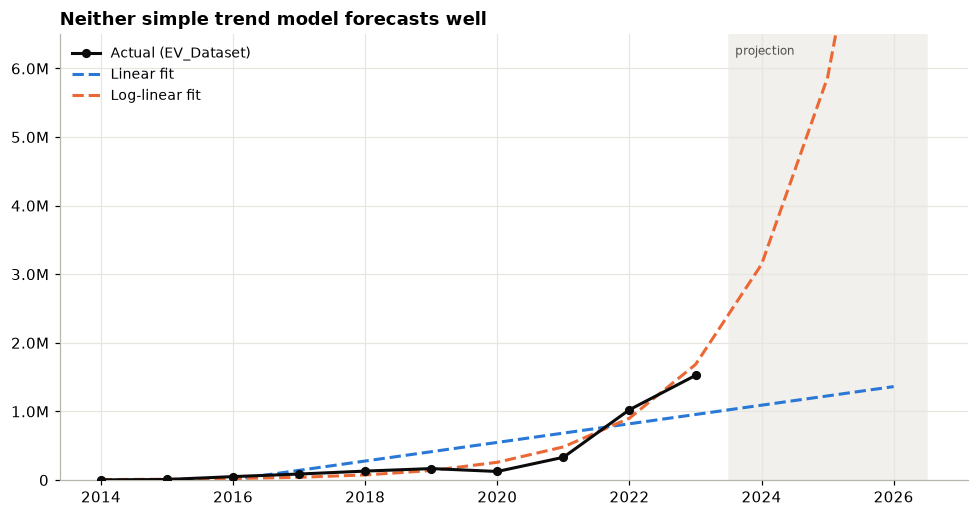

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.8))
yrs = np.arange(2014, 2027)
ax.plot(full_years.index, full_years.values, "o-", color="#0b0b0b", label="Actual (EV_Dataset)", zorder=4)
ax.plot(yrs, lin_f(yrs), "--", color=C[0], label="Linear fit")
ax.plot(yrs, log_f(yrs), "--", color=C[1], label="Log-linear fit")
ax.axvspan(2023.5, 2026.5, color="#f1f0ec", zorder=0)
ax.text(2023.6, 6.2e6, "projection", fontsize=8, color="#52514e")
ax.set_ylim(0, 6.5e6)
thousands(ax)
ax.set_title("Neither simple trend model forecasts well")
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

**What the forecast comparison shows:**
- **Linear is wrong in shape.** It underpredicted the 2022–23 backtest by more than two-thirds. Its 2024 value is *below* the 2023 actual (−28%), which contradicts January 2024 running 39% above January 2023.
- **Log-linear fits history well but likely overshoots the future.** It did well in the backtest, but it assumes the 2014–2023 average growth rate (≈87% a year) continues, which implies +106% in 2024. Actual growth had already slowed to +49% in 2023, and January 2024 was +39% year on year. A single month is a weak signal, but it points the same way as the 2023 slowdown. The model's 2026 figure (~11M) is not credible.
- **The honest conclusion is that ten annual points cannot support a forecast.** The data is consistent with a market moving from early exponential growth towards a slower phase (the classic S-curve), though one year of slowdown cannot confirm it. A defensible forecast would need monthly data, a saturation model, and external drivers such as changes to subsidy schemes. That is out of scope here, so **no point forecast is presented as a finding.**

## 9. International benchmark (IEA)

### What changed
The original CAGR cell reported **India = −37.7% and USA = 0.0%**. The IEA file has one row per region × year × **mode** (Cars, Buses, Vans, Trucks) × **powertrain** (BEV, PHEV, FCEV). The original filter did not select mode or powertrain, so `.values[0]` picked whichever row came first. For India, that was a car row in one year and a bus row in another. Here the filter is passenger **cars**, and stock is summed over **BEV + PHEV** for each year. (FCEV is excluded, following the IEA's own "EV" definition; it is negligible in every region shown.)

In [23]:
regions = ["India", "China", "USA", "EU27", "World"]
hist_cars = iea[(iea["category"] == "Historical") & (iea["mode"] == "Cars")]

# Demonstrate the bug: rows per region-year under the original filter
orig = iea[(iea["parameter"] == "EV stock") & (iea["category"] == "Historical") & (iea["unit"] == "Vehicles")]
print("Rows per year under the original filter (2015, 2023):")
print(orig[orig["region"].isin(regions) & orig["year"].isin([2015, 2023])].groupby(["region", "year"]).size().unstack(), "\n")

stock = (hist_cars[(hist_cars["parameter"] == "EV stock") & hist_cars["powertrain"].isin(["BEV", "PHEV"])]
         .groupby(["year", "region"])["value"].sum().unstack()[regions])
assert stock.loc[2015:2023].notna().all().all()

cagr = pd.DataFrame({
    "stock 2015": stock.loc[2015], "stock 2023": stock.loc[2023],
    "CAGR 2015–23": (stock.loc[2023] / stock.loc[2015]) ** (1 / 8) - 1,
    "CAGR 2019–23": (stock.loc[2023] / stock.loc[2019]) ** (1 / 4) - 1,
})
cagr.style.format({"stock 2015": "{:,.0f}", "stock 2023": "{:,.0f}", "CAGR 2015–23": "{:.1%}", "CAGR 2019–23": "{:.1%}"})

Rows per year under the original filter (2015, 2023):
year    2015  2023
region            
China      7    12
EU27      12    12
India      2     6
USA        6     6
World     12    12 



,stock 2015,stock 2023,CAGR 2015–23,CAGR 2019–23
region,,,,
India,"4,400","150,390",55.5%,104.5%
China,"297,000","21,800,000",71.1%,59.5%
USA,"400,000","4,800,000",36.4%,34.9%
EU27,"250,000","8,100,000",54.5%,64.4%
World,"1,250,000","40,000,000",54.2%,53.5%


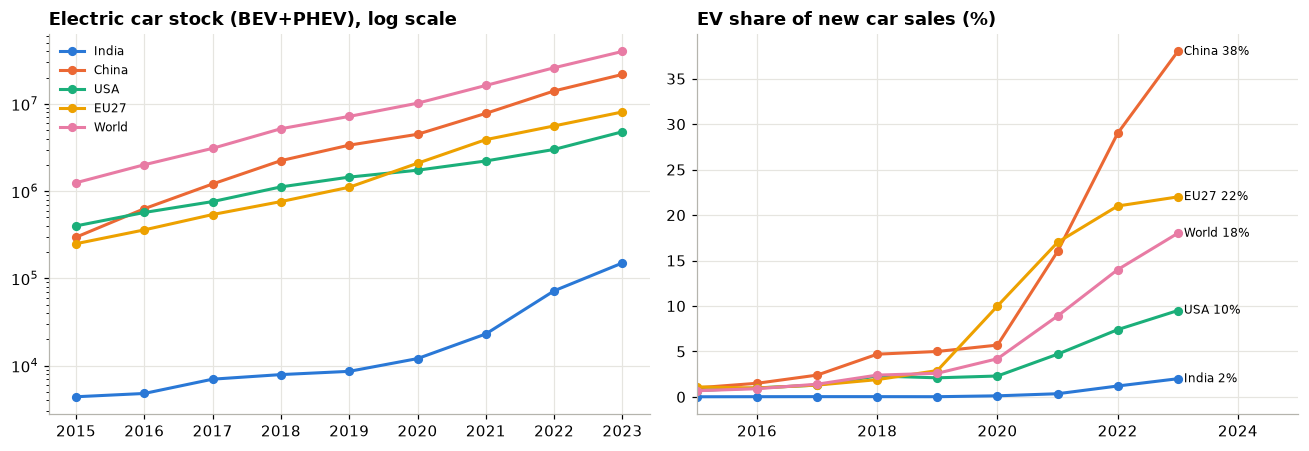

In [24]:
sales_share = (hist_cars[hist_cars["parameter"] == "EV sales share"]
               .pivot_table(index="year", columns="region", values="value")[regions].loc[2015:2023])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
for i, r in enumerate(regions):
    ax.plot(stock.loc[2015:2023].index, stock.loc[2015:2023, r], marker="o", color=C[i], label=r)
ax.set_yscale("log")
ax.set_title("Electric car stock (BEV+PHEV), log scale")
ax.legend(frameon=False, fontsize=8, ncol=1)
ax = axes[1]
for i, r in enumerate(regions):
    ax.plot(sales_share.index, sales_share[r], marker="o", color=C[i], label=r)
    ax.annotate(f"{r} {sales_share[r].iloc[-1]:.0f}%", (2023, sales_share[r].iloc[-1]), xytext=(4, 0),
                textcoords="offset points", fontsize=8, va="center")
ax.set_xlim(2015, 2025)
ax.set_title("EV share of new car sales (%)")
plt.tight_layout()
plt.show()

- With the filter fixed, India's electric **car** stock grew at **~56% a year 2015–23**, faster than the USA (~36%) and comparable to the EU and world averages (~54%). Over 2019–23 it grew fastest of all (~105% a year), but **from a very small base**: about 150,000 cars in 2023 against 21.8 million in China.
- India's electric share of new **car** sales was about **2% in 2023**, against 38% in China, 22% in the EU and 18% worldwide.
- **Caveat:** the IEA series covers cars, buses, vans and trucks only. India's EV market is 94% two- and three-wheelers (Section 6.1), so a car-only benchmark understates how far India's EV transition has actually gone. India is a laggard in electric cars, not necessarily in electric mobility.

## 10. Total cost of ownership: when does an electric car pay off?

### What changed
The original cell defined annual maintenance costs (₹3,000 EV, ₹7,000 ICE) but never used them. It concluded that an EV costs ₹34,000 more over five years. That conclusion followed almost entirely from the assumed ₹4 lakh price gap. A single-scenario TCO number is mostly a restatement of its inputs, so this section asks a better question: **at what ownership period, price gap and usage does the EV come out ahead?**

### Assumptions (from the original analysis; the running costs are treated as energy-only, with maintenance added separately)
| Input | EV | Petrol car |
|---|---|---|
| Purchase price | ₹12,00,000 | ₹8,00,000 |
| Energy cost per km | ₹0.90 | ₹7.00 |
| Maintenance per year | ₹3,000 | ₹7,000 |
| Distance per year | 12,000 km | 12,000 km |

**Not modelled**, all of which matter in practice: resale value, battery replacement, insurance, financing cost, discounting, and road-tax or registration differences between states. The model is undiscounted and per vehicle.

In [25]:
EV_PRICE, ICE_PRICE = 1_200_000, 800_000
EV_PER_KM, ICE_PER_KM = 0.9, 7.0
EV_MAINT, ICE_MAINT = 3_000, 7_000
KM = 12_000


def annual_saving(km=KM, ev_km=EV_PER_KM, ice_km=ICE_PER_KM, ev_m=EV_MAINT, ice_m=ICE_MAINT):
    return (ice_km - ev_km) * km + (ice_m - ev_m)


def breakeven_years(price_gap, **kw):
    return price_gap / annual_saving(**kw)


gap = EV_PRICE - ICE_PRICE
s = annual_saving()
print(f"Annual running-cost saving of the EV: ₹{s:,.0f}  (energy ₹{(ICE_PER_KM - EV_PER_KM) * KM:,.0f} + maintenance ₹{ICE_MAINT - EV_MAINT:,.0f})")
print(f"Breakeven at base case: {breakeven_years(gap):.1f} years")
for yrs in [5, 8]:
    print(f"After {yrs} years the EV is {'cheaper' if s * yrs > gap else 'dearer'} by ₹{abs(s * yrs - gap):,.0f}")
print(f"Maximum price gap at which the EV breaks even within 5 years: ₹{s * 5:,.0f}")

Annual running-cost saving of the EV: ₹77,200  (energy ₹73,200 + maintenance ₹4,000)
Breakeven at base case: 5.2 years
After 5 years the EV is dearer by ₹14,000
After 8 years the EV is cheaper by ₹217,600
Maximum price gap at which the EV breaks even within 5 years: ₹386,000


In [26]:
gaps = [100_000, 200_000, 300_000, 400_000, 500_000]
kms = [6_000, 9_000, 12_000, 15_000, 20_000]
be = pd.DataFrame([[breakeven_years(g, km=k) for k in kms] for g in gaps],
                  index=[f"₹{g / 1e5:.0f}L gap" for g in gaps], columns=[f"{k:,} km/yr" for k in kms])
print("Breakeven ownership period (years) by price gap and annual distance")
display(be.style.format("{:.1f}").background_gradient(cmap="Blues_r", vmin=0, vmax=10))

fuel = [5.0, 6.0, 7.0, 8.0, 9.0]
tco5 = pd.DataFrame([[5 * annual_saving(ice_km=f) - g for f in fuel] for g in gaps],
                    index=[f"₹{g / 1e5:.0f}L gap" for g in gaps], columns=[f"Petrol ₹{f:.0f}/km" for f in fuel])
print("5-year saving from choosing the EV (₹; negative = EV costs more), 12,000 km/yr")
display(tco5.style.format("{:,.0f}").background_gradient(cmap="RdBu", vmin=-300_000, vmax=300_000))

Breakeven ownership period (years) by price gap and annual distance


,"6,000 km/yr","9,000 km/yr","12,000 km/yr","15,000 km/yr","20,000 km/yr"
₹1L gap,2.5,1.7,1.3,1.0,0.8
₹2L gap,4.9,3.4,2.6,2.1,1.6
₹3L gap,7.4,5.1,3.9,3.1,2.4
₹4L gap,9.9,6.8,5.2,4.2,3.2
₹5L gap,12.3,8.5,6.5,5.2,4.0


5-year saving from choosing the EV (₹; negative = EV costs more), 12,000 km/yr


,Petrol ₹5/km,Petrol ₹6/km,Petrol ₹7/km,Petrol ₹8/km,Petrol ₹9/km
₹1L gap,"166,000","226,000","286,000","346,000","406,000"
₹2L gap,"66,000","126,000","186,000","246,000","306,000"
₹3L gap,"-34,000","26,000","86,000","146,000","206,000"
₹4L gap,"-134,000","-74,000","-14,000","46,000","106,000"
₹5L gap,"-234,000","-174,000","-114,000","-54,000","6,000"


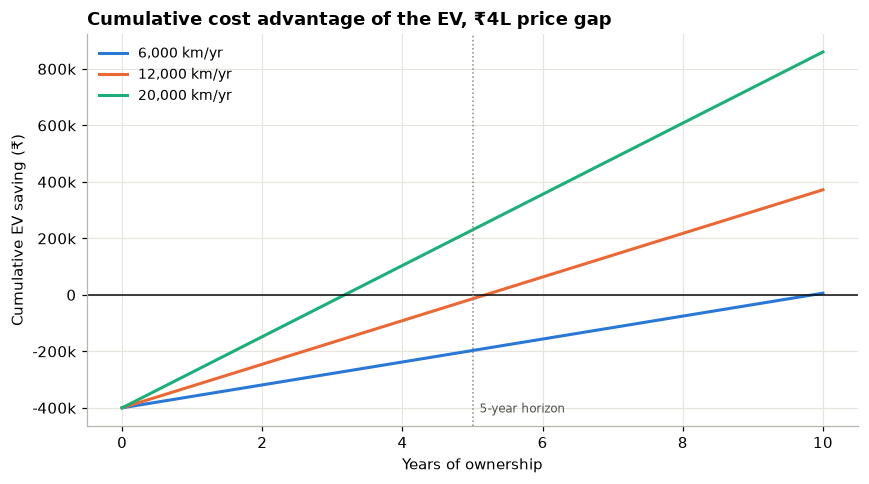

In [27]:
fig, ax = plt.subplots(figsize=(8, 4.5))
years = np.arange(0, 11)
for i, k in enumerate([6_000, 12_000, 20_000]):
    ax.plot(years, annual_saving(km=k) * years - gap, color=C[i], label=f"{k:,} km/yr")
ax.axhline(0, color="#0b0b0b", linewidth=1)
ax.axvline(5, color=GREY, linewidth=1, linestyle=":")
ax.text(5.1, ax.get_ylim()[0] * 0.9, "5-year horizon", fontsize=8, color="#52514e")
ax.set_xlabel("Years of ownership")
ax.set_ylabel("Cumulative EV saving (₹)")
thousands(ax)
ax.set_title(f"Cumulative cost advantage of the EV, ₹{gap / 1e5:.0f}L price gap")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

**What holds up:**
- At the base case, the EV saves about **₹77,000 a year** in running costs and **breaks even after about 5.2 years**. At five years it is about ₹14,000 behind; by year eight it is about ₹2.2 lakh ahead.
- **The answer depends on usage and on the price gap, not on the vehicle.** At 20,000 km a year, the base-case gap pays back in about 3.2 years. At 6,000 km a year it takes about 10. A ₹2 lakh gap breaks even in under 3 years at typical usage.
- At 12,000 km a year, the EV wins within five years whenever the price gap is below about **₹3.9 lakh**.

**What this does not show:** whether a given EV is cheaper to own. The inputs are illustrative averages. Resale value and battery replacement, which survey respondents named as concerns (50% cited battery cost), are not modelled and could move breakeven in either direction.

## 11. Summary and limitations

### Findings that hold up
1. **India's EV registrations reached ~1.53M in 2023** (excluding Telangana), up from 2,392 in 2014. Growth is clearly decelerating (+209% in 2022, +49% in 2023; January 2024 was +39% on January 2023).
2. **India's EV market is a two- and three-wheeler market:** they made up 94% of 2023 registrations. In electric cars specifically, India is far behind (≈2% of new car sales vs 18% globally).
3. **Adoption is geographically concentrated**, and it tracks charging infrastructure closely at the state level (rank correlation ≈ 0.9). **This association is not causal**, and state size confounds it.
4. **Among surveyed Indian residents, 44% (CI 36–53%) say their next vehicle is likely to be an EV, and 38% are undecided.**
5. **Charging infrastructure, upfront cost and battery replacement cost are each cited by about half of respondents.** They cannot be ranked against each other. Home is the preferred place to charge.
6. **Demographics do not predict intent in this sample.** Attitudes do, but that is close to circular.
7. **EV vs petrol-car economics depend on distance driven and the price gap.** Under the stated assumptions, breakeven takes about 5 years at 12,000 km/year.

### Findings withdrawn from the original capstone
- India's EV CAGR of −37.7% and the USA's 0.0% (a filtering bug).
- The forecast of 882,017 EVs for 2025 (it treated a partial year as a full one), and the ARIMA forecast (the model did not converge).
- 75.6% accuracy as evidence of a predictive model, and "very positive opinion" as a "driver" of adoption.
- The RandomForest vs logistic-regression comparison (different targets).
- "EVs cost ₹34,000 more over 5 years" as a finding.

### Limitations
- **Convenience sample.** It skews to Kerala, the Gulf diaspora, women and graduates. Results describe these respondents, not Indian consumers in general.
- **Self-reported intent.** Stated purchase intent usually overstates actual purchases.
- **Small n.** With 125 Indian residents, any share carries an uncertainty of roughly ±9 points, and subgroup differences under about 20 points cannot be detected reliably.
- **No causal claims.** Every relationship reported is an association.
- **Data gaps.** Telangana is missing from the registration data; the charger data has no stated source or snapshot date; the IEA benchmark excludes two- and three-wheelers.
- **Anonymisation.** To protect respondents, the published survey file suppresses some employment, region and age values (see `scripts/anonymise_survey.py`). Analyses that use these columns treat "Suppressed" as its own category.